# ENERGY — Feature Importance Analysis (Sreeram_experimental)

Per-asset-class cluster importance under the Jay-CSV labels.
Follows Harry's workflow: cluster MDA + MDI + SHAP, cross-method
rank agreement, within-cluster PCA + SHAP breakdown for top clusters,
global per-feature SHAP, and a pruned-vs-full CPCV(6,2) AUC
comparison.

All artifacts come from
`results/sreeram_experimental/importance/energy/` — produced
by `python -m stml.experimental.make_importance` (cluster summary)
and `python -m stml.experimental.make_importance_deep` (within-cluster
+ global SHAP + pruned-model comparison).


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 240)

ASSET_CLASS = 'energy'
REPO = Path.cwd()
while not (REPO / 'pyproject.toml').exists():
    REPO = REPO.parent
OUT = REPO / 'results' / 'sreeram_experimental' / 'importance' / ASSET_CLASS
print('Loading from:', OUT)


Loading from: /Volumes/Sreeram/Systematic/stml/results/sreeram_experimental/importance/energy


## 1. Cluster cross-check

Cluster ranks under each importance method, plus the
`significant` flag (MDA mean > 1 sigma above zero -> lower CI > 0).


In [2]:
crosscheck = pd.read_csv(OUT / 'cluster_crosscheck_table.csv')
crosscheck


,cluster_id,n_members,members,mda_mean,mda_rank,mdi_sum,mdi_rank,shap_sum,shap_rank,significant
0,8,3,"f5_participation_60,f7_oi_level,ewma_hmm_prob_...",0.117782,1,0.188587,1,0.795587,1,True
1,1,6,"f1_bb_pctb_20,f1_rsi_14,f6_ts_momentum_20,f10_...",0.003830,2,0.073121,5,0.300837,6,False
2,4,7,"f19_atm_iv_1m,f19_atm_iv_3m,f2_vol_60,f2_vol_o...",0.003542,3,0.100497,3,0.338376,4,False
3,6,3,"f11_be10y_chg20,f11_ust10_chg5,f11_be10y_chg5",0.002778,4,0.037701,10,0.137484,10,False
4,7,3,"f11_dxy_chg20,f11_eurusd_chg20,f11_dxy_chg5",0.002302,5,0.027478,13,0.129030,12,True
5,14,3,"f19_skew_1m,f5_long_bias_20,f7_overnight_gap",0.001167,6,0.068834,7,0.239281,8,False
6,10,2,"f7_volume_z_20,f7_volume_trend_20",0.000573,7,0.023715,15,0.124317,13,False
7,12,4,"f18_term_spread_z63,f5_flip_rate_60,f8_month_c...",-0.000228,8,0.039225,9,0.130470,11,False
8,15,2,"f12_variance_ratio_5_21,f12_autocorr_21",-0.000351,9,0.029864,12,0.091108,15,False
9,5,7,"f11_vix_rank63,f11_move_rank63,f11_vix_chg20,f...",-0.000579,10,0.076693,4,0.412168,3,False


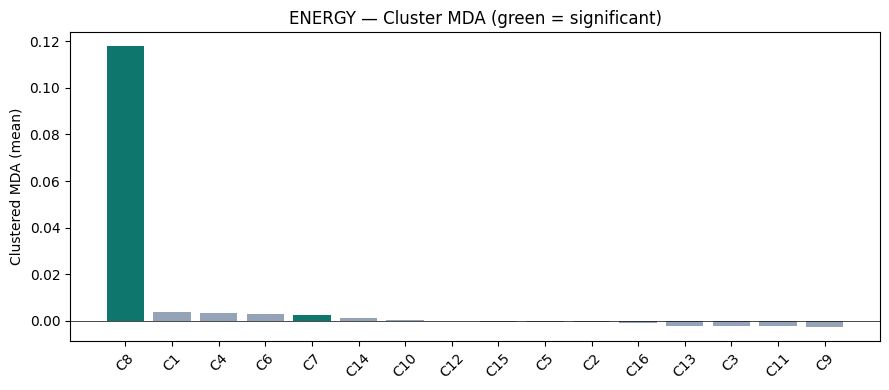

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(crosscheck))
ax.bar(x, crosscheck['mda_mean'],
       color=['#0F766E' if s else '#94a3b8' for s in crosscheck['significant']])
ax.set_xticks(x)
ax.set_xticklabels([f'C{int(c)}' for c in crosscheck['cluster_id']], rotation=45)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Clustered MDA (mean)')
ax.set_title('ENERGY — Cluster MDA (green = significant)')
plt.tight_layout(); plt.show()


## 2. Kendall rank agreement (MDA vs MDI vs SHAP)

Rank agreement across the three importance methods.
tau ~ 0.7+: methods agree (the typical pattern is MDI <-> SHAP).
tau < 0.4: methods disagree (typical: MDA <-> SHAP, since MDA is
the out-of-sample reality check).


In [4]:
rank_agree = pd.read_csv(OUT / 'rank_agreement.csv')
rank_agree


,metric_a,metric_b,kendall_tau,p_value
0,mdi_sum_mean,mda_mean,0.233333,0.228134
1,gain_sum_mean,mda_mean,0.233333,0.228134
2,mdi_sum_mean,gain_sum_mean,1.000000,0.000000
3,shap_sum_mean,mda_mean,0.183333,0.350195
4,shap_sum_mean,mdi_sum_mean,0.816667,0.000001


## 3. Within-cluster breakdown (top clusters by MDA)

For each top cluster: cluster members ranked by mean |SHAP|,
plus the PC1/PC2/PC3 loadings from a PCA fit on standardised
members. `pca_pc1_var_explained` >= 65% indicates a single latent
dimension (one representative suffices); 40-65% indicates a dominant
direction; < 40% indicates multi-dimensional structure.


In [5]:
import glob
wc_paths = sorted(glob.glob(str(OUT / 'within_cluster_C*.csv')))
wc_paths


['/Volumes/Sreeram/Systematic/stml/results/sreeram_experimental/importance/energy/within_cluster_C14_f7.csv',
 '/Volumes/Sreeram/Systematic/stml/results/sreeram_experimental/importance/energy/within_cluster_C1_f1.csv',
 '/Volumes/Sreeram/Systematic/stml/results/sreeram_experimental/importance/energy/within_cluster_C4_f11.csv',
 '/Volumes/Sreeram/Systematic/stml/results/sreeram_experimental/importance/energy/within_cluster_C4_f12.csv',
 '/Volumes/Sreeram/Systematic/stml/results/sreeram_experimental/importance/energy/within_cluster_C5_f7.csv',
 '/Volumes/Sreeram/Systematic/stml/results/sreeram_experimental/importance/energy/within_cluster_C8_f7.csv']

In [6]:
for p in wc_paths:
    name = Path(p).stem.replace('within_cluster_', '')
    df = pd.read_csv(p)
    pc1 = df['pca_pc1_var_explained'].iloc[0] * 100
    pc2 = df['pca_pc2_var_explained'].iloc[0] * 100 if 'pca_pc2_var_explained' in df.columns else 0
    print(f'--- {name}: PC1 = {pc1:.1f}%, PC1+PC2 = {pc1+pc2:.1f}%, {len(df)} members ---')
    display(df)


--- C14_f7: PC1 = 57.9%, PC1+PC2 = 81.7%, 3 members ---


,feature,cluster,mean_shap_mag,pc1_loading,pca_pc1_var_explained,pc2_loading,pca_pc2_var_explained,pc3_loading,pca_pc3_var_explained
0,f7_oi_level,14,0.632650,-0.534123,0.578922,0.821941,0.238348,0.197803,0.18273
1,f5_participation_60,14,0.183079,0.611314,0.578922,0.213888,0.238348,0.761936,0.18273
2,ewma_hmm_prob_highvol,14,0.025728,0.583959,0.578922,0.527887,0.238348,-0.616707,0.18273


--- C1_f1: PC1 = 77.1%, PC1+PC2 = 88.7%, 6 members ---


,feature,cluster,mean_shap_mag,pc1_loading,pca_pc1_var_explained,pc2_loading,pca_pc2_var_explained,pc3_loading,pca_pc3_var_explained
0,f1_bb_pctb_20,1,0.202944,0.372843,0.770904,0.619144,0.116465,0.432162,0.050842
1,f1_rsi_14,1,0.126370,0.434497,0.770904,0.333802,0.116465,0.056978,0.050842
2,f15_semi_vol_ratio_20,1,0.087438,-0.408632,0.770904,0.082798,0.116465,0.706951,0.050842
3,f12_trend_tval_21,1,0.047241,0.415543,0.770904,0.133728,0.116465,-0.335808,0.050842
4,f10_oc_ret_mean_20,1,0.045861,0.397930,0.770904,-0.527386,0.116465,0.393976,0.050842
5,f6_ts_momentum_20,1,0.040489,0.417369,0.770904,-0.449847,0.116465,0.205490,0.050842


--- C4_f11: PC1 = 54.6%, PC1+PC2 = 75.4%, 4 members ---


...

,feature,cluster,mean_shap_mag,pc1_loading,pca_pc1_var_explained,pc2_loading,pca_pc2_var_explained,pc3_loading,pca_pc3_var_explained
0,f12_hurst_100,4,0.093198,0.293390,0.653193,0.652750,0.120661,0.514716,0.092906
1,f9_pair_corr_mean_63,4,0.064921,-0.315263,0.653193,-0.265587,0.120661,0.827874,0.092906
2,f2_vol_60,4,0.058342,0.404566,0.653193,0.097387,0.120661,0.042223,0.092906
3,f19_atm_iv_1m,4,0.036118,0.402865,0.653193,-0.422820,0.120661,0.086553,0.092906
4,f19_atm_iv_3m,4,0.034530,0.427946,0.653193,-0.246158,0.120661,-0.019475,0.092906
5,f2_vol_of_vol_20,4,0.027668,0.397712,0.653193,-0.397592,0.120661,0.197552,0.092906
6,f9_implied_corr_z_252,4,0.024964,-0.383725,0.653193,-0.310558,0.120661,0.031792,0.092906


--- C5_f7: PC1 = 97.6%, PC1+PC2 = 100.0%, 2 members ---


,feature,cluster,mean_shap_mag,pc1_loading,pca_pc1_var_explained,pc2_loading,pca_pc2_var_explained
0,f7_volume_z_20,5,0.108676,0.707107,0.976123,0.707107,0.023877
1,f7_volume_trend_20,5,0.061928,0.707107,0.976123,-0.707107,0.023877


--- C8_f7: PC1 = 58.5%, PC1+PC2 = 84.5%, 3 members ---


,feature,cluster,mean_shap_mag,pc1_loading,pca_pc1_var_explained,pc2_loading,pca_pc2_var_explained,pc3_loading,pca_pc3_var_explained
0,f7_oi_level,8,0.565700,-0.483750,0.584533,0.859103,0.260433,0.167116,0.155035
1,f5_participation_60,8,0.485004,0.635564,0.584533,0.213556,0.260433,0.741925,0.155035
2,ewma_hmm_prob_highvol,8,0.045165,0.601701,0.584533,0.465119,0.260433,-0.649322,0.155035


## 4. Global per-feature SHAP

Mean |SHAP|, signed mean SHAP, and MDI per feature on the
asset-class modelling sample. Top features here that aren't in any
significant cluster are candidates for the pruned model.


In [7]:
gshap = pd.read_csv(OUT / 'global_shap_summary.csv')
display(gshap.head(25))


,feature,shap_magnitude,shap_signed,mdi
0,f7_oi_level,0.565700,-0.264336,0.033905
1,f5_participation_60,0.485004,-0.233153,0.037713
2,f10_oc_ret,0.261877,-0.003229,0.011120
3,f7_overnight_gap,0.247158,-0.026681,0.012398
4,f11_vix_chg5,0.221197,0.007666,0.014871
5,f1_bb_pctb_20,0.202944,-0.008628,0.016045
6,f11_dxy_chg5,0.188413,0.014153,0.012831
7,f5_trailing_run_length,0.187116,-0.016743,0.016939
8,f11_skew_rank63,0.158356,0.006528,0.014817
9,f7_volume_z_20,0.152649,-0.000866,0.014731


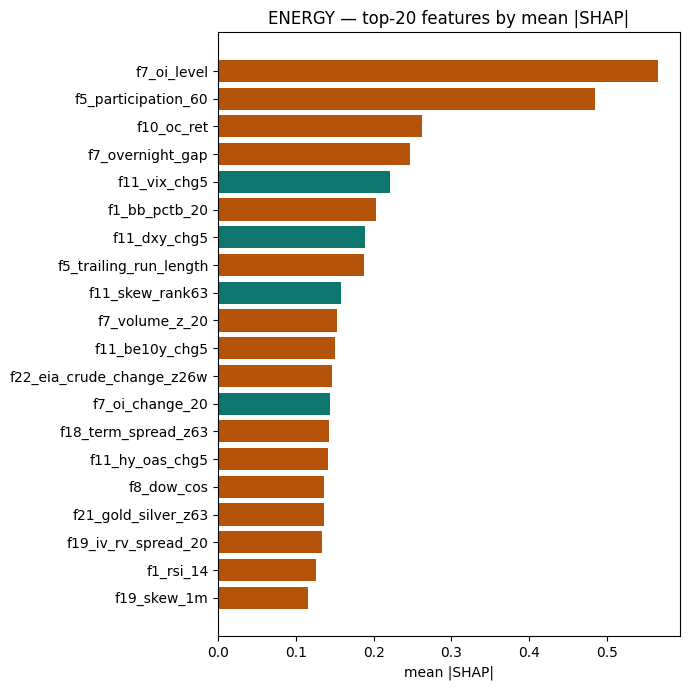

In [8]:
fig, ax = plt.subplots(figsize=(7, 7))
top = gshap.head(20).iloc[::-1]
colors = ['#0F766E' if v > 0 else '#B45309' for v in top['shap_signed']]
ax.barh(range(len(top)), top['shap_magnitude'], color=colors)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top['feature'])
ax.set_xlabel('mean |SHAP|')
ax.set_title('ENERGY — top-20 features by mean |SHAP|')
plt.tight_layout(); plt.show()


## 5. Pruned model — selection rule

Selection rule (per Harry / user spec):

1. For each significant cluster (MDA mean > 1 sigma):
   - PC1 >= 65% -> one representative (the top SHAP member).
   - PC1 + PC2 >= 75% -> two representatives.
   - Otherwise -> top-2 by mean |SHAP|.
2. Plus the global top-5 SHAP features not in any chosen cluster.


In [9]:
with open(OUT / 'pruned_features.json') as f:
    pruned = json.load(f)
print(f"Pruned feature set ({pruned['n_pruned']} features):")
for feat in pruned['features']:
    print(f"  - {feat:<35}  {pruned['reasons'][feat]}")


Pruned feature set (5 features):
  - f7_oi_level                          cluster 8: PC1+PC2 84% -> two reps
  - f5_participation_60                  cluster 8: PC1+PC2 84% -> two reps
  - f10_oc_ret                           global SHAP top-5
  - f7_overnight_gap                     global SHAP top-5
  - f11_vix_chg5                         global SHAP top-5


## 6. Full vs pruned model — honest held-out val AUC

Importance + global SHAP + cluster selection all computed on the
**train** partition only. Pruned features picked from train.
Both models then fit on **train** and scored on the **held-out val**
partition (never used for selection). The val AUC reported here is
an honest out-of-sample estimate of the pruning effect.


In [10]:
cmp = pd.read_csv(OUT / 'pruned_vs_full_auc.csv')
cmp


,model,n_features,n_val,val_auc,val_sem
0,full,74,297,0.625125,0.032505
1,pruned,5,297,0.608187,0.032812


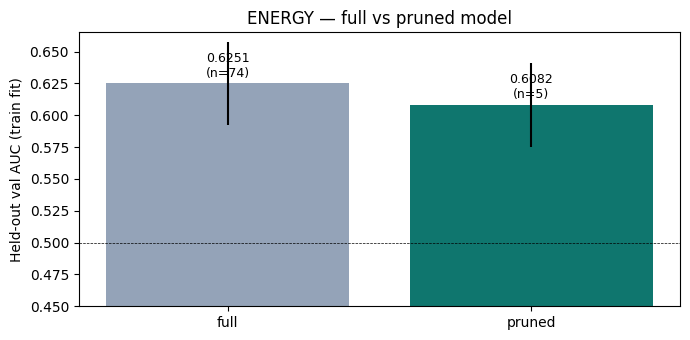

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(cmp['model'], cmp['val_auc'],
       yerr=cmp['val_sem'],
       color=['#94a3b8', '#0F766E'])
ax.axhline(0.5, color='black', linewidth=0.5, linestyle='--')
ax.set_ylim(0.45, max(cmp['val_auc']) + 0.04)
for i, (m, a, n) in enumerate(zip(cmp['model'], cmp['val_auc'], cmp['n_features'])):
    ax.text(i, a + 0.005, f'{a:.4f}\n(n={int(n)})', ha='center', fontsize=9)
ax.set_ylabel('Held-out val AUC (train fit)')
ax.set_title('ENERGY — full vs pruned model')
plt.tight_layout(); plt.show()


## 7. Findings note (plain-text summary)

Auto-generated summary: significant clusters, top SHAP features,
the pruned feature list, and the CPCV AUC comparison.


In [12]:
print((OUT / 'findings_note.txt').read_text())


=== ENERGY — feature importance findings ===

Modelling sample: 668 events; 68 features after hygiene.
Significant clusters (MDA mean > 1 sigma): 2 of 16.

Top significant clusters (by MDA):
  C8: 3 members, MDA +0.1178 +/- 0.0000, top SHAP member = f7_oi_level, PC1 var = 58%
  C7: 3 members, MDA +0.0023 +/- 0.0000, top SHAP member = ?, PC1 var = 0%

Top 10 global features by mean |SHAP|:
  f7_oi_level                         |SHAP| = 0.5657
  f5_participation_60                 |SHAP| = 0.4850
  f10_oc_ret                          |SHAP| = 0.2619
  f7_overnight_gap                    |SHAP| = 0.2472
  f11_vix_chg5                        |SHAP| = 0.2212
  f1_bb_pctb_20                       |SHAP| = 0.2029
  f11_dxy_chg5                        |SHAP| = 0.1884
  f5_trailing_run_length              |SHAP| = 0.1871
  f11_skew_rank63                     |SHAP| = 0.1584
  f7_volume_z_20                      |SHAP| = 0.1526

Pruned feature set (5 features):
  - f7_oi_level  (cluster 8: PC1+P